## Data Exploration & preparation

ในโน้ตบุ๊กนี้ เราจะสำรวจข้อมูลภาพจากดาต้าเซ็ต `Fashion MNIST`  
เพื่อให้เข้าใจว่า:
- ข้อมูลมีลักษณะเป็นอย่างไร
- มีรูปภาพทั้งหมดกี่คลาส
- ตัวอย่างภาพในแต่ละคลาสหน้าตาเป็นอย่างไร

เป้าหมายคือเตรียมความเข้าใจก่อนนำไปใช้ฝึกโมเดล Deep Learning


In [11]:
# TensorFlow and tf.keras
import matplotlib.pyplot as plt

# Helper libraries
import numpy as np
import tensorflow as tf
import cv2

# print(tf.reduce_sum(tf.random.normal([1000, 1000])))
print(tf.config.list_physical_devices())  # แสดง processor ที่สามารถรัน tensorflow ได้
from tensorflow import keras
from tensorflow.python.client import device_lib

print(tf.__version__)
print(keras.__version__)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
2.21.0
3.15.0


**ดึงข้อมูลเข้ามาในเครื่อง** หากเรารันเซลล์ด้านล่างนี้และเครื่องไม่พบชุดข้อมูล 
โปรแกรมจะทำการดาวน์โหลดชุดข้อมูลจากอินเตอร์เน็ตมาให้โดยอัตโนมัติ ดังนั้นหากเราจะรันเซลล์นี้เป็นครั้งแรกของเครื่อง เราอาจจะต้องเตรียมการเชื่อมต่ออินเตอร์เน็ตเอาไว้ด้วย

In [3]:
fashion_mnist = keras.datasets.fashion_mnist

## โหลด Dataset: Fashion MNIST

Fashion MNIST เป็นดาต้าเซ็ตตัวอย่างที่นิยมใช้ในการเรียนรู้ Deep Learning แบบ supervised  
โดยสามารถโหลดชุดข้อมูลฝึกและทดสอบได้โดยตรงจาก `tensorflow.keras.datasets`

---

### dataset ประกอบด้วย:
ในโค้ดส่วน `(train_images, train_labels), (test_images, test_labels)`
- `train_images`: ภาพสำหรับฝึกโมเดล  
- `train_labels`: เฉลยของภาพฝึก
- `test_images`: ภาพสำหรับทดสอบโมเดล
- `test_labels`: เฉลยของภาพทดสอบ

---

### แนวคิด Training:

- ระบบจะใช้ `train_images` และ `train_labels` เพื่อเรียนรู้ว่า:
  - ภาพลักษณะนี้ควรมีคำตอบอะไร
  - ถ้าตอบผิด → ปรับพารามิเตอร์ (weight) ให้เข้าใกล้คำตอบที่ถูกต้อง
  - ถ้าตอบถูก → ปรับให้ "มั่นใจ" ในคำตอบนั้นมากขึ้น (ต่อให้ตอบถูกก็ยังมี error อยู่นิดหน่อยต้องปรับให้มั่นใจมากขึ้นด้วย!)
- สรุปคือ **โมเดลจะอัปเดต weight เพื่อให้ตอบได้แม่นยำขึ้นเรื่อย ๆ**

---

### แนวคิดเบื้องหลังการทดสอบ (Testing):

- ใช้ `test_images` โดยไม่ปรับพารามิเตอร์ใด ๆ
- ระบบจะทำนายคำตอบ แล้วเปรียบเทียบกับ `test_labels` เพื่อประเมินความแม่นยำ

---
<font color="red">

### หมายเหตุ:

- ในการทดลองที่ดี **ชุด train และ test ควรไม่ซ้ำกันเลย (disjoint set)**
- เฉลยถูกเก็บไว้ใน `train_labels` และ `test_labels` เท่านั้น — **ตอนใช้งานจริงจะไม่มีเฉลยให้แล้ว**
</font>
การเข้าใจโครงสร้างและวัตถุประสงค์ของดาต้าเซ็ตนี้เป็นพื้นฐานที่สำคัญ ก่อนนำไปใช้ในการฝึกและประเมินผลโมเดล Deep Learning ครับ


In [4]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# สังเกตุแรมที่เพิ่มขึ้น

**การโหลด dataset มานั้นไม่จำเป็นจะต้องโหลดด้วยโค้ดแบบด้านบนเสมอไป ต้องดูด้วยว่าตัว manual นั้นเขียนไว้อย่างไร**

## Explore the data
ในส่วนนี้เป็นการสำรวจว่าข้อมูลที่ได้มานั้นมีลักษณะเป็นอย่างไร 

### เราใช้ชุดทดสอบในการฝึกโมเดลได้ไหม? (สำคัญ)

จริงๆ แล้ว โมเดล **ไม่รู้เลย** ว่าข้อมูลไหนเป็น “ชุดฝึก” หรือ “ชุดทดสอบ”  
เพราะทั้งขนาดภาพและรูปแบบของเฉลย (label) เหมือนกันหมด  
เราต่างหากที่เป็นคนตั้งชื่อให้เองเพื่อให้ง่ายต่อการจัดการ

ถ้าเราเอาข้อมูลจากชุดทดสอบไปรวมในการฝึก โมเดลก็จะยอมรับและฝึกตามปกติ  
แต่สิ่งที่เราควรทำคือ **แยกข้อมูลเป็น 2 ชุด** เพื่อจะได้ใช้ชุดทดสอบในการประเมินผลที่เป็นกลาง

> ⚠️⚠️ <font color="blue">**ข้อควรระวัง:** อย่าเผลอเอาชุดทดสอบไปรวมตอนฝึก</font></br>
> เพราะจะทำให้ผลการทดสอบไม่น่าเชื่อถือ — โมเดลอาจจะ "จำเฉลย" ได้แทนที่จะเรียนรู้จริง

---

### การตั้งชื่อ “ประเภท” ที่ต้องการให้โมเดลจำแนก

ในงานจำแนกประเภท (Classification) เราจะต้องกำหนด “ชื่อประเภท” หรือ **class labels** ด้วยตัวเอง
> ภายใน trains_label และ test_labels จะเป็นลิสที่มีสมาชิกเป็น `0, 1, 2, 3, 4, ..., 9`

โดยทั่วไป เราจะใช้ **ลิสต์ของสตริง** เพื่อ map ให้ตรงกับชื่อของแต่ละประเภทจริงๆ เช่น:

```python
class_names = ['T-shirt/top', 'Trouser', ...]
```
คลาสในเฉลยที่เป็น 0 จะเท่ากับว่าเป็นรูปภาพของ `T-shirt/top`

### <font color="red">แบบฝึกหัดที่ 1 </font>
จงดู doc ที่ keras นั้นมีไว้ให้ >> **[fashion_mnist](https://keras.io/api/datasets/fashion_mnist/)**
ภายใน doc จะบอกว่า class นั้นมีอะไรบ้าง จงเติม `class_names` ให้ครบตามที่ doc นั้นระบุไว้

In [5]:
# พื้นที่สำหรับตอบคำถามด้วยโค้ด
class_names = [
    "T-shirt/top",
    "Trouser",
	"Pullover",
	"Dress",
	"Coat",
	"Sandal",
	"Shirt",
	"Sneaker",
	"Bag",
	"Ankle boot"    
]
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [6]:
train_images.shape

(60000, 28, 28)

ผลลัพธ์ด้านบนเป็น ขนาดและ มิติ ของอาเรย์ที่โหลดเข้ามา

In [7]:
len(train_labels) # จำนวนภาพ

60000

In [8]:
train_labels.shape

(60000,)

In [9]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## อธิบายผลลัพธ์ที่ได้จาก `train_labels`

- ข้อมูลใน `train_labels` เป็น **NumPy array** ที่มีความยาว **60,000 ช่อง**  
- เมื่อข้อมูลมีจำนวนมาก Python จะแสดงแค่ **3 ตัวแรกและ 3 ตัวสุดท้าย** เพื่อให้ดูง่ายขึ้น

---

### `dtype=uint8` คืออะไร?

- `dtype` ย่อมาจาก **data type** หรือชนิดของข้อมูล
- `uint8` คือ **unsigned integer 8-bit**  
  ใช้แทนค่าตัวเลขตั้งแต่ **0 ถึง 255**
- โดยทั่วไป `uint8` มักใช้แทน **ค่าความสว่างของพิกเซล (Grayscale)**  
  - `0` = ดำสนิท  
  - `255` = ขาวจ้า

> ⚠️ **แต่ในกรณีนี้ `train_labels` ไม่ได้เก็บค่าพิกเซล**  
> มันเก็บ “หมายเลขประเภทของสิ่งของ” ที่ใช้ในการจำแนก แล้วทำไมใช้ `uint8` หละ?

---

### ทำไมถึงใช้ `uint8` กับ `train_labels` แทน `int32`?

- เพราะเรามีแค่ **10 ประเภท (class)** ซึ่งก็คือเลขตั้งแต่ `0` ถึง `9`
- การใช้ `uint8` จึง **เพียงพอและประหยัดหน่วยความจำ** กว่า `int32` (กินเนื้อที่ในแรมมากเกินไป)

---

### การเชื่อมโยงกับ `class_names`

ตัวเลขใน `train_labels` จะ **ตรงกับตำแหน่งในลิสต์ `class_names`**

เช่น:
```python
train_labels[:3]  ->  [9, 0, 0]
class_names[train_labels[0]] -> 'Ankle boot' # คลาสที่ 9 คือบูทหุ้มข้อ
```
เดี๋ยวเราจะไปใช้ตอนแสดงผลลัพธ์ เราคงไม่อยากให้การทำนายออกมาทายว่าเป็นคลาสที่ 0 หรือ คลาสที่ 9 เพราะว่ามันจะเข้าใจยากเกินไป แสดงเป็นสตริงจะดีกว่า

## แสดงตัวอย่างภาพด้วยการ plot
- ขั้นตอนนี้สำคัญมากเพราะเราควรหมั่นตรวจว่า ข้อมูลที่เราได้มาถูกต้องจริงหรือไม่?
- การแสดงข้อมูลออกมาเป็นรูปภาพนั้นช่วยให้เราตรวจสอบความถูกต้องของชุดข้อมูลนี้ได้ง่าย

ในที่นี้เราจะดึงข้อมูลภาพอันแรกออกมา ซึ่งก็คือ train_images[0]

- Code นี้เป็นการเรียกใช้งาน matplotlib ที่มีชื่อเล่นว่า plt
- จะเห็นได้ว่าเราสามารเรียกฟังก์ชัน imshow() เพื่อที่จะแสดงภาพออกมาได้ เพียงแค่เราใส่ np.ndarray เข้าไปด้านใน

<class 'numpy.ndarray'>


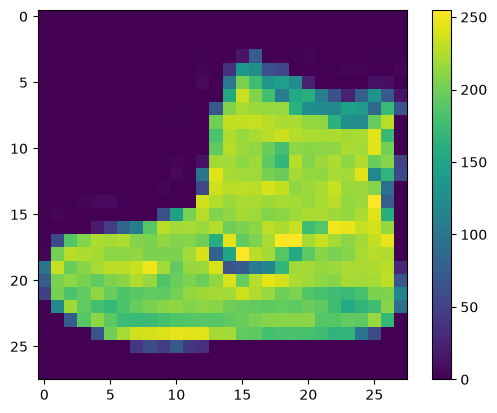

In [16]:
print(type(train_images[0]))
# plt.figure()
# plt.imshow(cv2.cvtColor(train_images[0], cv2.COLOR_RGB2BGR))
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)

### Subplot
ฟังก์ชัน subplot นั้นเป็นการ plot รูป หรือ กราฟหลายกราฟในคราวเดียวโดยจะจัดการแสดงผลอยู่ในรูปแบบของตาราง
โดยในที่นี้เราจะต้องกำหนดก่อนว่าจะให้ตารางมีขนาดเท่าไหร่ แถว, หลัก ตามด้วย index ของกราฟ(เริ่มที่ 1)

>`plt.subplot(1,2,1)` กำลังบอกว่า มี 1 แถว 2 คอลลัมน์ และจะทำการพล็อตรูปที่ 1
>
>`plt.subplot(1,2,2)` กำลังบอกว่า มี 1 แถว 2 คอลลัมน์ และจะทำการพล็อตรูปที่ 2

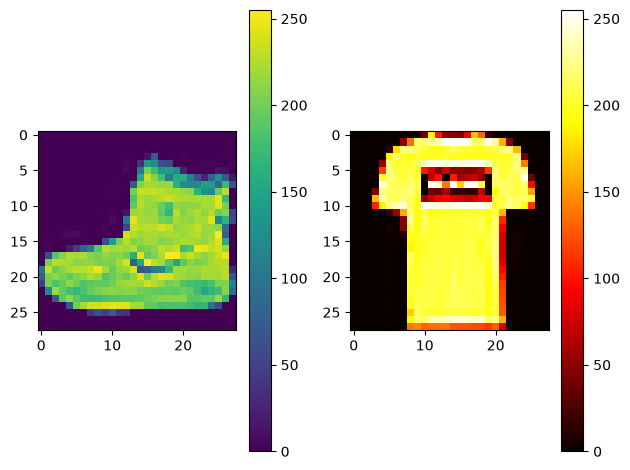

In [21]:
plt.figure()
plt.subplot(1,2,1) 
plt.imshow(train_images[0])
plt.colorbar()

plt.subplot(1,2,2)
# plt.imshow(train_images[1]) # top right
# plt.imshow(cv2.cvtColor(train_images[1], cv2.COLOR_RGB2BGR), cmap = 'hot')
plt.imshow(train_images[1], cmap = 'hot')
plt.colorbar()

plt.tight_layout()
plt.grid(False)

เราสามารถพิมพ์ออกมาได้ด้วยว่าคลาสของรูปใดๆนั้นคืออะไรโดยการเรียก `print(train_labels[n])`
ตัวอย่างด้านล่างเป็นการพิมพ์ คลาสของภาพที่ 10 ผลลัพธ์ก็คือคลาสที่ 0 หรือ `T-shirt/top`

In [11]:
print(train_labels[14])
print(class_names[train_labels[14]])

7
Sneaker


### <font color="red">แบบฝึกหัดที่ 2 plotting</font>
1. จงพล็อตโดยการใช้ imshow หรือ subplot+imshow ภาพที่ 15, 2000, 15000, และ 50000 ออกมา
   > หากอยากใช้ subplot ลองใช้ `subpolot(2, 2, n)` เพิ่ม n ไปเรื่อยๆจนครบ 4
2. จงพิมพ์คลาสของภาพที่ 15, 2000, 15000, และ 50000 ออกมาเป็นสตริง
   > สามารถใช้ `class_names[train_labels[n]]` ถ้าอยากได้ชื่อคลาสเป็น text

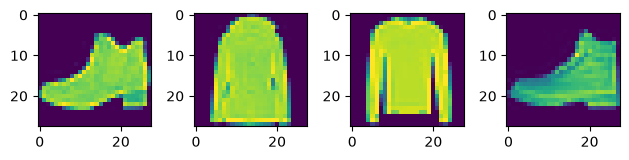

In [12]:
# plot รูปออกมา 4 รูป
plt.subplot(1, 4, 1)
plt.imshow(train_images[15])

plt.subplot(1, 4, 2)
plt.imshow(train_images[2000])

plt.subplot(1, 4, 3)
plt.imshow(train_images[15000])

plt.subplot(1, 4, 4)
plt.imshow(train_images[50000])


plt.tight_layout()
plt.show()

In [13]:
# print class ของรูปที่ต้องการ
print(class_names[train_labels[15]])
print(class_names[train_labels[2000]])
print(class_names[train_labels[15000]])
print(class_names[train_labels[50000]])

Ankle boot
Coat
Pullover
Ankle boot



## Loop ploting images
จริงๆแล้วเราสามารถ loop เพื่อ plot ได้เช่นกัน
จะเห็นว่าค่า i นั้นถูกนำไปใช้ตรง `subplot(3, 4, ...)` เพราะเพิ่มรูปทีละ 1

**ข้อสังเกตุ** สิ่งที่อยากให้สนใจคือ parametre `cmap` เป็นตัวแปรที่ย่อมาจากคำว่า colour map ซึ่งเป็นตัวแปรที่บอกว่าจะแปลงค่าเลข 0-255 ออกมาเป็นสีอะไร `cmap="grey"` ในตัวอย่างจะให้ผลลัพธ์เป็น "สีเฉดเทา"
> โค้ดที่อยากให้ลองแก้ไขตัวเลขคือ
>
> `range(..)`, `subplot(3, .., ..)`, และ `figsize(.., ..)` 

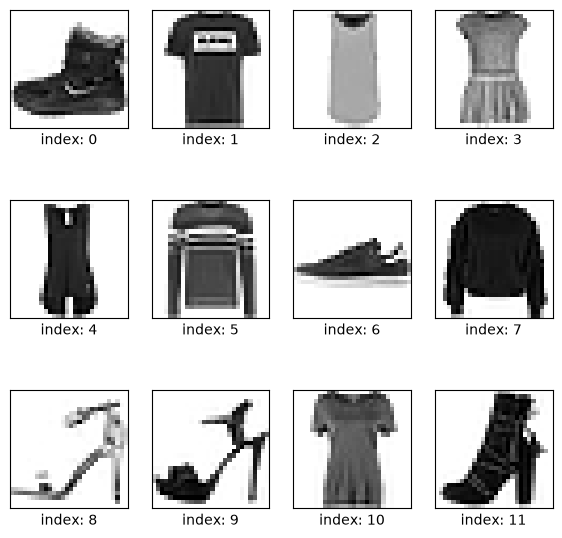

In [14]:
plt.figure(figsize=(7, 7)) # ปรับขนาดกราฟ
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap="binary")
    plt.xlabel(f"index: {i}")

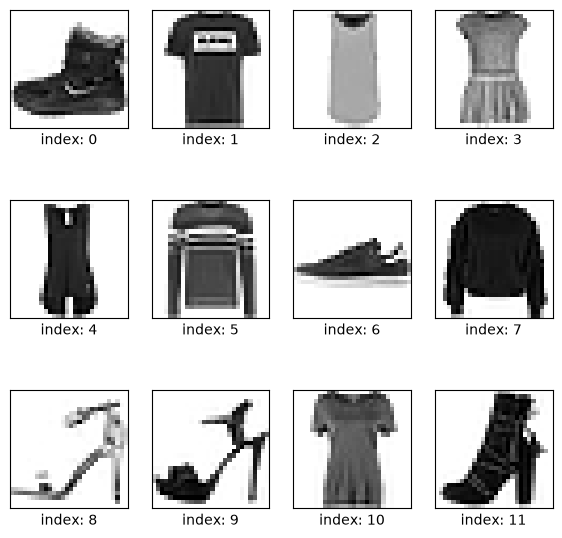

In [22]:
plt.figure(figsize=(7, 7)) # ปรับขนาดกราฟ
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap="gray_r")
    plt.xlabel(f"index: {i}")

### ตัวอย่างที่ 2 loop plotting 
ด้านล่างจะเป็นโค้ดที่ทำการพล็อตรูปบน grid 6x5 ทั้งหมด 30 รูป

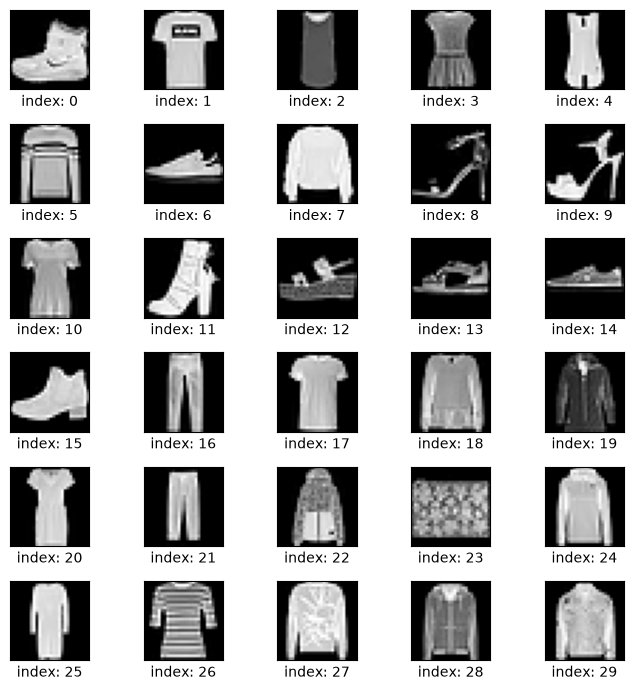

In [24]:
# พล็อตแบบ 6 x 5 
plt.figure(figsize=(7, 7)) # ปรับขนาดกราฟ
for i in range(30):
    plt.subplot(6, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap=plt.cm.grey)
    plt.xlabel(f"index: {i}")
plt.tight_layout()

### <font color="red">แบบฝึกหัดที่ 3</font>
จงใช้ `subplot()` 
- พล็อตรูปที่ 100 ถึง 140 (แก้ไข start, stop ของ range())
- บน grid 5x8
- figsize ขนาด 10 x 10
- แก้ไข `cmap` ให้เป็นเฉดสีที่เราชอบ สามารถดูได้จาก >[cmap](https://matplotlib.org/stable/gallery/color/colormap_reference.html)< (อย่าใช้เวลาเยอะนะครับ มี lab อีกไฟล์)
    > สมมติว่าอยากได้ Pastel1 สามารถใส่ได้ 2 วิธี คือ `cmap="Pastel1"` หรือ `cmap=plt.cm.Pastel1`
- แทนที่จะใช้ xlabel เป็น index: ... แก้ไขให้แสดง ชื่อคลาสที่เป็น text แทน เช่นขึ้นว่า "Shirt" ใต้รูป

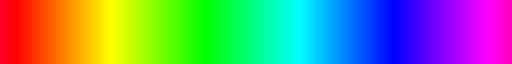

In [17]:
#ถ้าต้องการดูตัวอย่างสี สามารถเรียกออกมาดูได้ด้วย
plt.cm.gist_rainbow

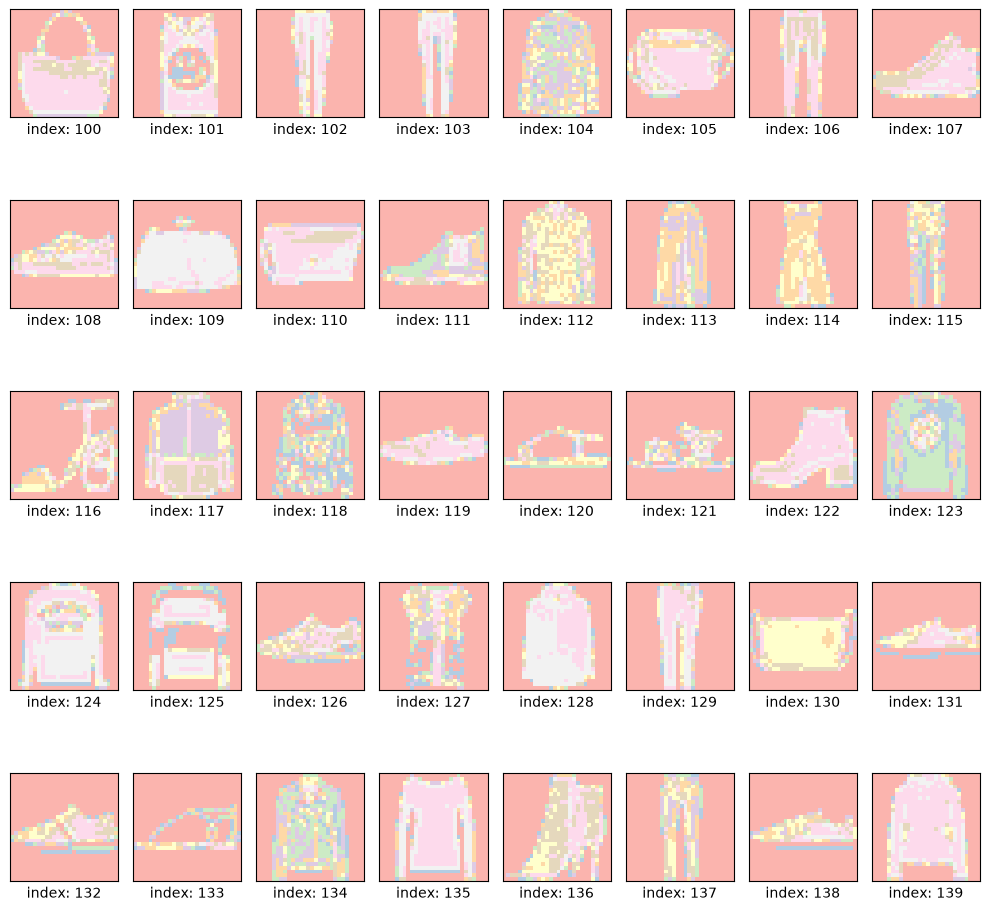

In [30]:
# พื้นที่ตอบคำถามแบบฝึกที่ 3
plt.figure(figsize=(10,10))
# print(len(train_images))
for i in range(40):
    plt.subplot(5, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i+100], cmap="Pastel1")
    plt.xlabel(f"index: {i+100}")
plt.tight_layout()

## ดูการกระจายตัวของ class (distribution)

การตรวจสอบ **class distribution** (การกระจายตัวของคลาส) เป็นขั้นตอนสำคัญในการสำรวจข้อมูลก่อนฝึกโมเดล เพราะ:

- ช่วยให้เรารู้ว่าแต่ละคลาสมีจำนวนข้อมูลใกล้เคียงกันหรือไม่
- ถ้าข้อมูลไม่สมดุล (เช่น บางคลาสมีข้อมูลมาก บางคลาสมีน้อย)
    - โมเดลจะถูกฝึกกับคลาสใดคลาสหนึ่งมากเกินไป ทำให้เมื่อโมเดลไม่รู้จะตอบอะไรก็ตอบคลาสนี้ โอกาสถูกจะสูงสุด
- เมื่อพบว่า distribution ไม่สมดุล เราจะสามารถวางแผนรับมือได้ (เดี๋ยวสอนในอนาคต)

---

ฟังก์ชัน `np.unique()` ใช้เพื่อ **ดึงค่าที่ไม่ซ้ำกันทั้งหมด** จากอาเรย์หนึ่ง ๆ  
พูดง่าย ๆ คือมันจะคืนรายการของ **ค่าที่แตกต่างกันทั้งหมด** ที่ปรากฏในข้อมูล โดยจะเรียงลำดับให้อัตโนมัติ

**syntax**
```python
np.unique(array)
# หรือ หากต้องการ count ของแต่ละค่าด้วย
np.unique(array, return_counts=True)


Text(0.5, 1.0, 'Class Distribution')

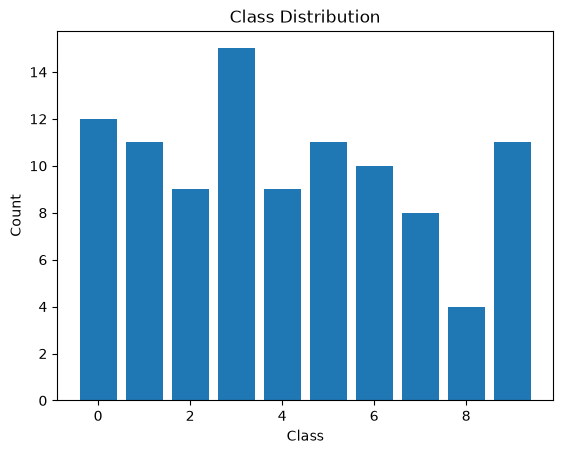

In [19]:
classes, counts = np.unique(train_labels[:100], return_counts=True)
plt.bar(classes, counts) # bar graph
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")

### <font color="red">แบบฝึกหัดที่ 4 class distribution</font>

1. จากกราฟด้านบน class ที่เท่าไหร่ที่มีจน.เยอะมากที่สุดในเฉลยของชุดฝึก 100 อันแรก และมีชื่อคลาสว่าอะไร
2. จงใช้โค้ดด้านบนสร้างกราฟขึ้นมาใหม่แต่จะใช้เฉลยของ**ชุดฝึก(train)** 1000 อันแรก
3. จงใช้โค้ดด้านบนสร้างกราฟขึ้นมาใหม่แต่จะใช้เฉลยของ**ชุดทดสอบ(test)** 1000 อันแรก
4. จากข้อ 2 คลาสที่มีจน.ภาพเยอะสุดคือคลาสใด และ จากข้อ 3 คลาสที่จน.ภาพเยอะสุดคือคลาสใด เป็นคลาสเดียวกันหรือไม่?
5. จากข้อ 4 หากเราทำภาพ**ชุดฝึก(train)** แค่ 1000 ภาพแรกไปฝึกโมเดลและทดสอบด้วย**ชุดทดสอบ(test)** เราคิดว่ามันแฟร์ไหม? โมเดลจะมีการเอนเอียงไหม?

### **พื้นที่ตอบคำถามแบบฝึกที่ 4.1**

class_names[3] = Dress






Text(0.5, 1.0, 'Class Distribution')

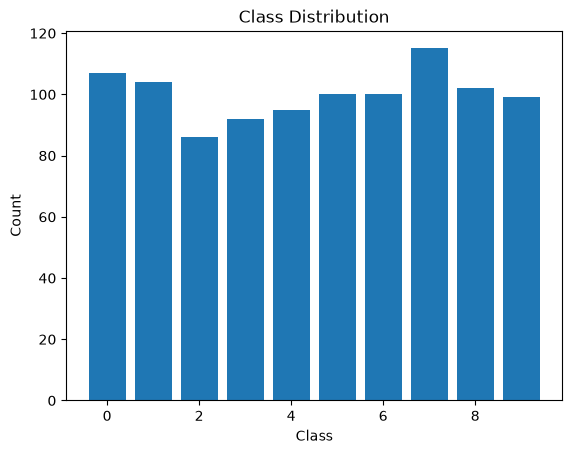

In [20]:
# **พื้นที่ตอบคำถามแบบฝึกที่ 4.2
classes, counts = np.unique(train_labels[:1000], return_counts=True)
plt.bar(classes, counts) # bar graph
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")


Text(0.5, 1.0, 'Class Distribution')

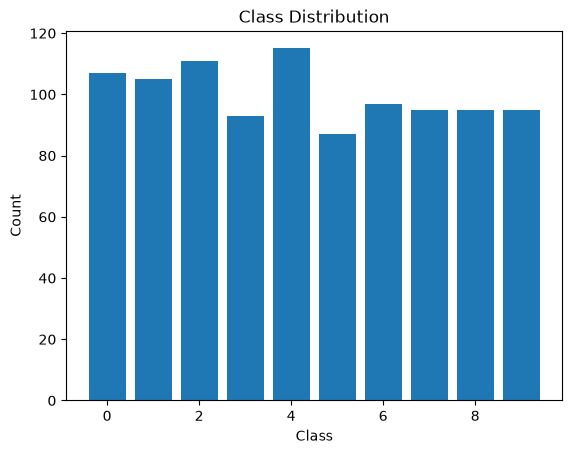

In [21]:
# **พื้นที่ตอบคำถามแบบฝึกที่ 4.3
classes, counts = np.unique(test_labels[:1000], return_counts=True)
plt.bar(classes, counts) # bar graph
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")




**พื้นที่ตอบคำถามแบบฝึกที่ 4.4**

from question 2: class_names[3] = dress

from question 3: class_names[7] = pullover

so they aren't the same

**พื้นที่ตอบคำถามแบบฝึกที่ 4.5**

I think it is fair to use the test_labels for the first 1000 values because the graph so that most class_names are greater than 80. 